In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.collections import LineCollection
from matplotlib.colors import ListedColormap, BoundaryNorm, LinearSegmentedColormap, Normalize
from mpl_toolkits.mplot3d.art3d import Line3DCollection
from mpl_toolkits.mplot3d import proj3d
import torch
import dnnlib.util_v5 as util
from tqdm import tqdm
import pickle
from matplotlib.ticker import FuncFormatter
import gc
from PIL import Image
import matplotlib as mpl

import numpy as np
import pickle
import os
import re 
import json 
import click
import torch
from torch_utils import distributed as dist
from training import toy_training_loop_vfm_noDataGen
from tqdm import tqdm
import matplotlib.pyplot as plt
from matplotlib import colors
from plot_neural import *
from plot_sim_results_v6 import *
from plot_sim_results_img_v6 import * 
from plot_musal_v5 import * 
import pickle, types
from torch_utils import persistence

import pandas as pd

import warnings
warnings.filterwarnings('ignore', 'Grad strides do not match bucket view strides') # False warning 
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
torch.set_default_device(device)
colorgrad = "PuOr"

# 1. Functions

In [2]:
@torch.no_grad()
def _fit_line_from_seeds_pca(x0: torch.Tensor, idx: torch.Tensor):
    """
    Representative line from seeds (no origin involved):
      c = centroid of seed points
      u = first right-singular vector of (X_seeds - c), unit
    """
    Xs  = x0[idx].float()
    c   = Xs.mean(0)
    Xzc = Xs - c
    Vh  = torch.linalg.svd(Xzc, full_matrices=False).Vh
    u   = Vh[0]
    u   = u / (torch.norm(u) + 1e-12)
    return c, u

@torch.no_grad()
def _dist_to_line(X: torch.Tensor, c: torch.Tensor, u: torch.Tensor):
    """
    Per-point perpendicular distance r to the infinite line {c + t*u}.
    """
    Xmc = X - c
    s   = Xmc @ u
    r   = torch.linalg.norm(Xmc - torch.outer(s, u), dim=1)
    return r

@torch.no_grad()
def bands_from_seed_lines_fixed_radius(
    x0: torch.Tensor,
    seed1: torch.Tensor,
    seed2: torch.Tensor,
    seed3: torch.Tensor,
    *,
    radii: tuple = (0.05, 0.05, 0.05),  # manual radii (R1, R2, R3) in latent units
    margin: float = 0.0                 # optional: require r_owner + margin < min r_other
):
    """
    1) Fit 3 lines via PCA on each seed block -> (c_k, u_k).
    2) Compute distances r_k from every point to each line.
    3) Unique ownership = nearest line (argmin over k).
    4) Keep point i in band k iff (owner(i)==k) AND (r_k(i) <= R_k) AND margin condition.

    Returns:
      band1_idx, band2_idx, band3_idx, unassigned_idx   (all LongTensors on x0.device)
    """
    dev = x0.device
    X   = x0.detach().float().to(dev)

    # lines from seeds
    c1,u1 = _fit_line_from_seeds_pca(X, seed1)
    c2,u2 = _fit_line_from_seeds_pca(X, seed2)
    c3,u3 = _fit_line_from_seeds_pca(X, seed3)

    # distances to each line
    r1 = _dist_to_line(X, c1, u1)
    r2 = _dist_to_line(X, c2, u2)
    r3 = _dist_to_line(X, c3, u3)

    R = torch.stack([r1, r2, r3], dim=1)     # [N,3]
    owners = torch.argmin(R, dim=1)          # nearest line index (0,1,2)

    # margin check (optional)
    if margin > 0.0:
        big = torch.tensor(float('inf'), device=dev)
        r_owner = R[torch.arange(X.size(0), device=dev), owners]
        r_other_min = torch.minimum(
            torch.where(owners != 0, R[:,0], big),
            torch.minimum(torch.where(owners != 1, R[:,1], big),
                          torch.where(owners != 2, R[:,2], big))
        )
        margin_ok = r_owner + margin < r_other_min
    else:
        margin_ok = torch.ones(X.size(0), dtype=torch.bool, device=dev)

    R1, R2, R3 = [torch.as_tensor(v, device=dev, dtype=X.dtype) for v in radii]

    keep1 = (owners == 0) & (r1 <= R1) & margin_ok
    keep2 = (owners == 1) & (r2 <= R2) & margin_ok
    keep3 = (owners == 2) & (r3 <= R3) & margin_ok

    band1_idx = torch.nonzero(keep1, as_tuple=False).squeeze(1)
    band2_idx = torch.nonzero(keep2, as_tuple=False).squeeze(1)
    band3_idx = torch.nonzero(keep3, as_tuple=False).squeeze(1)

    kept = keep1 | keep2 | keep3
    unassigned_idx = torch.nonzero(~kept, as_tuple=False).squeeze(1)

    return band1_idx, band2_idx, band3_idx, unassigned_idx

In [3]:
def _light_red_cmap(alpha_max=0.95, alpha_min=0.10,
                    red_rgb=(1.0, 0.45, 0.45), deepen=0.15):
    """
    alpha_max: opacity for largest gradients (0..1)
    alpha_min: baseline opacity so faint gradients are still visible
    red_rgb:   base red tint (R,G,B)
    deepen:    how much to further reduce G,B at the top stop (more = stronger red)
    """
    r, g, b = red_rgb
    top_rgba = (1.0, max(0.0, g - deepen), max(0.0, b - deepen), alpha_max)  # deeper red + more opaque
    low_rgba = (1.0, 1.0, 1.0, alpha_min)                                    # white with some opacity
    return LinearSegmentedColormap.from_list("white_to_stronger_red", [low_rgba, top_rgba])

In [4]:
def plot_mu_trajectories_gradient_steps_3d(
    mu_traj_np,                   # list of arrays [T_i, D]
    trial_indices=None,           # iterable of trial ids to plot; None => all
    dims=(0, 1, 2),               # which μ dims (0-based)
    start_color="#fdae61",
    end_color="#313695",
    linewidth=2.0,
    alpha=0.5,                    # line alpha
    start_marker_size=36,
    start_marker_alpha=0.95,
    end_arrow_alpha=0.95,
    arrow_head_frac=0.03,         # head length as fraction of per-trial diagonal
    arrow_length_ratio=0.6,
    title="Latent trajectories",
    fig_w=7, fig_h=6,
    decimate=1,                   # plot every k-th step along each trial (speed-up)
    z_scale='auto',               # 'auto', 'none', or a number to multiply z values by
    aspect_ratio=(1, 1, 1),       # visual aspect ratio for the box
    elev_azim=None,               # tuple (elev, azim)
    # NEW:
    labels=None,                  # per-trial values -> color each whole trajectory
    label_mode='auto',            # 'auto' | 'continuous' | 'categorical'
    cmap=None,                    # None -> Matplotlib default (e.g., 'viridis') for continuous; tab10 for categorical
    vrange=None,                  # (vmin, vmax) for continuous labels
    cbar_label=None,               # override colorbar label (continuous labels)
    circmap = 'twilight',
    show_start=True,
    show_end=True,
    show_arrow=False,
):
    # ----- choose trials -----
    if trial_indices is None:
        trial_indices = range(len(mu_traj_np))

    # ----- gather trajectories -----
    trajs, max_len = [], 0
    for idx in trial_indices:
        S = mu_traj_np[idx]
        if S is None or S.size == 0:
            continue
        trajs.append((idx, S))
        max_len = max(max_len, S.shape[0])
    if not trajs:
        raise ValueError("No non-empty trials to plot.")

    # ----- compute data ranges for auto-scaling -----
    all_x, all_y, all_z = [], [], []
    for _, S in trajs:
        all_x.extend(S[:, dims[0]].tolist())
        all_y.extend(S[:, dims[1]].tolist())
        all_z.extend(S[:, dims[2]].tolist())
    x_range = (max(all_x) - min(all_x)) if all_x else 1
    y_range = (max(all_y) - min(all_y)) if all_y else 1
    z_range = (max(all_z) - min(all_z)) if all_z else 1

    # ----- determine z scaling factor -----
    if z_scale == 'auto':
        xy_avg_range = (x_range + y_range) / 2
        scale_factor = (xy_avg_range / z_range) if z_range > 0 else 1.0
    elif z_scale == 'none':
        scale_factor = 1.0
    else:
        scale_factor = float(z_scale)

    # ===== label mode setup (if labels given) =====
    use_labels = labels is not None
    lab_for = {}
    use_cont = False
    cats = None
    cmap_obj = None
    norm = None

    if use_labels:
        # build per-trial label lookup
        if isinstance(labels, dict):
            for idx, _S in trajs:
                if idx in labels:
                    lab_for[idx] = labels[idx]
        else:
            arr = np.asarray(labels)
            for idx, _S in trajs:
                if idx < arr.shape[0]:
                    lab_for[idx] = arr[idx]

        vals_exist = [lab_for[i] for i, _ in trajs if i in lab_for]
        if len(vals_exist) == 0:
            raise ValueError("Provided labels are empty or misaligned with trials.")

        # decide continuous vs categorical
        if label_mode == 'continuous':
            use_cont = True
        elif label_mode == 'categorical':
            use_cont = False
        else:  # 'auto'
            all_int = all(isinstance(v, (int, np.integer)) for v in vals_exist)
            all_num = all(isinstance(v, (int, float, np.integer, np.floating)) for v in vals_exist)
            use_cont = (not all_int) and all_num

        if use_cont:
            vals = np.array(vals_exist, dtype=float)
            if vrange is None:
                vmin, vmax = float(np.nanmin(vals)), float(np.nanmax(vals))
                # if looks like degrees in [-180, 180], lock it
                if (vmin >= -180-1e-6) and (vmax <= 180+1e-6):
                    vmin, vmax = -180.0, 180.0
            else:
                vmin, vmax = vrange

            if np.isclose(vmin, -180.0) and np.isclose(vmax, 180.0) and cmap is None:
                cmap_obj = plt.get_cmap(circmap)
            else:
                default_name = plt.rcParams.get('image.cmap', 'viridis')
                cmap_obj = plt.get_cmap(default_name if cmap is None else cmap)
            
            norm = Normalize(vmin=vmin, vmax=vmax)
        else:
            # categorical palette
            cats = []
            for idx, _ in trajs:
                if idx in lab_for:
                    v = lab_for[idx]
                    if v not in cats:
                        cats.append(v)
            if cmap is None:
                base = plt.get_cmap('tab10')
                cmap_obj = ListedColormap([base(i % base.N) for i in range(len(cats))])
            else:
                cmap_obj = plt.get_cmap(cmap)
            norm = BoundaryNorm(np.arange(len(cats)+1)-0.5, len(cats))
            cat_to_i = {c: i for i, c in enumerate(cats)}
    else:
        cmap_obj = None
        norm = None
        color_cycle = plt.rcParams['axes.prop_cycle'].by_key().get('color', ['#1f77b4'])
        idx_to_color = {idx: color_cycle[j % len(color_cycle)] for j, (idx, _) in enumerate(trajs)}

    # ----- figure & axes -----
    fig = plt.figure(figsize=(fig_w, fig_h))
    ax = fig.add_subplot(111, projection="3d")
    ax.grid(False)
    for axis in (ax.xaxis, ax.yaxis, ax.zaxis):
        try:
            axis.pane.set_facecolor((1, 1, 1, 0))
            axis.pane.set_edgecolor((1, 1, 1, 0))
        except Exception:
            pass
        try:
            axis._axinfo["grid"]["linewidth"] = 0
        except Exception:
            pass

    

    # ----- track global data limits (with scaled z) -----
    xmin = ymin = zmin_scaled = np.inf
    xmax = ymax = zmax_scaled = -np.inf

    # ===== plot =====
    for idx, S in trajs:
        # dims + scale z
        x = np.asarray(S[:, dims[0]], dtype=float)
        y = np.asarray(S[:, dims[1]], dtype=float)
        z_raw = np.asarray(S[:, dims[2]], dtype=float)
        z = z_raw * scale_factor

        # decimate
        if decimate > 1:
            x = x[::decimate]; y = y[::decimate]; z = z[::decimate]; z_raw = z_raw[::decimate]
        T = x.shape[0]
        if T == 0:
            continue

        # update global bounds (scaled z)
        xmin = min(xmin, x.min()); xmax = max(xmax, x.max())
        ymin = min(ymin, y.min()); ymax = max(ymax, y.max())
        zmin_scaled = min(zmin_scaled, z.min()); zmax_scaled = max(zmax_scaled, z.max())

        # start marker
        if use_labels:
            if idx in lab_for:
                color = cmap_obj(norm(float(lab_for[idx]))) if use_cont else cmap_obj(norm(cat_to_i[lab_for[idx]]))
            else:
                color = (0.6, 0.6, 0.6, 1.0)
        else:
            color = idx_to_color[idx]
        
        # start marker
        color = "k"
        
        if T > 1:
            # build segments: [(x0,y0,z0)->(x1,y1,z1), (x1,y1,z1)->(x2,y2,z2), ...]
            pts  = np.column_stack([x, y, z])           # (T, 3)
            segs = np.stack([pts[:-1], pts[1:]], 1)     # (T-1, 2, 3)
        
            lc = Line3DCollection(
                segs,
                colors=[(0.0, 0.0, 0.0, float(alpha))],  # black with your alpha
                linewidths=linewidth,
                antialiaseds=False                       # crisper density
            )
            ax.add_collection3d(lc)
        
        if show_start:
            ax.scatter(x[0], y[0], z[0], s=start_marker_size, marker="o",
                       facecolor=color, edgecolor="black",
                       linewidths=0.5, alpha=start_marker_alpha, zorder=3)
        
        if show_end:
            if show_arrow and T > 1:
                dx, dy, dz = x[-1]-x[-2], y[-1]-y[-2], z[-1]-z[-2]
                uv = np.array([dx, dy, dz], float)
                nrm = float(np.linalg.norm(uv))
                rng = np.array([x.max()-x.min(), y.max()-y.min(), z.max()-z.min()])
                diag = float(np.linalg.norm(rng))
                head_len = max(1e-12, arrow_head_frac * (diag if diag > 0 else 1.0))
                min_head = 0.02 * max(rng.max(), 1e-12)
                head_len = max(head_len, min_head)
        
                if nrm >= 1e-12:
                    u_hat = uv / nrm
                    tail = np.array([x[-1], y[-1], z[-1]]) - u_hat * head_len
                    ax.quiver(tail[0], tail[1], tail[2],
                              u_hat[0], u_hat[1], u_hat[2],
                              length=head_len, normalize=False,
                              color=color, linewidth=linewidth*1.2,
                              arrow_length_ratio=arrow_length_ratio,
                              alpha=end_arrow_alpha)
                else:
                    ax.scatter(x[-1], y[-1], z[-1],
                               s=start_marker_size*0.9, marker="^",
                               facecolor=color, edgecolor="black",
                               linewidths=0.5, alpha=end_arrow_alpha, zorder=3)
            else:
                ax.scatter(x[-1], y[-1], z[-1],
                           s=start_marker_size*0.9, marker="^",
                           facecolor=color, edgecolor="black",
                           linewidths=0.5, alpha=end_arrow_alpha, zorder=3)

    # ----- labels & view -----
    ax.set_xlabel(f"μ{dims[0]+1}")
    ax.set_ylabel(f"μ{dims[1]+1}")
    ax.set_zlabel(f"μ{dims[2]+1}")
    ax.set_title(title)

    # limits + aspect
    # --- Let Matplotlib autoscale using the exact points we plotted (with z scaling) ---
    xs, ys, zs = [], [], []
    for idx, S in trajs:
        x = np.asarray(S[:, dims[0]], float)
        y = np.asarray(S[:, dims[1]], float)
        z = np.asarray(S[:, dims[2]], float) * scale_factor
        if decimate > 1:
            x = x[::decimate]; y = y[::decimate]; z = z[::decimate]
        if x.size:
            xs.append(x); ys.append(y); zs.append(z)
    
    if xs:  # concatenate and hand to the built-in autoscaler
        xs = np.concatenate(xs); ys = np.concatenate(ys); zs = np.concatenate(zs)
        ax.auto_scale_xyz(xs, ys, zs, had_data=False)
    
        # Optional: tiny uniform pad so points aren't glued to the box
        dx = max(1e-12, xs.max() - xs.min())
        dy = max(1e-12, ys.max() - ys.min())
        dz = max(1e-12, zs.max() - zs.min())
        pad = 0.03  # 3% visual padding
        ax.set_xlim(xs.min() - pad*dx, xs.max() + pad*dx)
        ax.set_ylim(ys.min() - pad*dy, ys.max() + pad*dy)
        ax.set_zlim(zs.min() - pad*dz, zs.max() + pad*dz)
    
    # Aspect: keep data aspect unless you explicitly pass something else
    try:
        if aspect_ratio == (1, 1, 1):
            ax.set_box_aspect('auto')   # natural data aspect (no forced cube)
        else:
            ax.set_box_aspect(aspect_ratio)
    except Exception:
        pass

    if elev_azim is not None:
        ax.view_init(elev=elev_azim[0], azim=elev_azim[1])

    # rescale tick labels on z back (if we visually scaled z)
    if scale_factor != 1.0:
        ax.zaxis.set_major_formatter(
            FuncFormatter(lambda val, pos: f"{val/scale_factor:.2f}")
        )

In [6]:
def plot_3d_with_pts(mu_traj_sim, title, group_idx, dot_col, show_idx = False, alpha = 0.05, lag = 5):
    plot_mu_trajectories_gradient_steps_3d(
        mu_traj_sim,
        trial_indices=np.arange(len(mu_traj_sim)), 
        dims=(0,1,2),
        linewidth=0.1,
        alpha=alpha,
        title=title ,
        z_scale='auto',  # Automatically scales z to be visually comparable to x and y
        aspect_ratio=(1, 1, 1),
        circmap = colorgrad,
        elev_azim = (30, 45),
        show_start = False,
        show_end = False
    )

    x0 = mu_traj_sim[0]                # [T,3] torch
    ax = plt.gca()  # the function’s axes are current
    x0_np = x0.detach().cpu().numpy()
    ii = group_idx.numpy()
    ax.scatter(
        x0_np[ii, 0], x0_np[ii, 1], x0_np[ii, 2] * scale,
        s=40, marker='.', facecolors=dot_col,
        edgecolors=dot_col, linewidths=1.8
    )
    if show_idx:
        for j in ii: ax.text(x0_np[j,0]+ 0.02,
                             x0_np[j,1] + 0.02,
                             (x0_np[j,2] + 0.02)*scale, str(j + lag),
                             fontsize=8, color = dot_col)
    plt.draw()

In [68]:
def plot_3d_with_pts_all(mu_traj_sim, group_idx_all, dot_col_all, show_idx=False, alpha=0.05, lag=5, labels_all=None, post_adjust=None):
    plot_mu_trajectories_gradient_steps_3d(
        mu_traj_sim,
        trial_indices=np.arange(len(mu_traj_sim)), 
        dims=(0,1,2),
        linewidth=0.1,
        alpha=alpha,
        title=None,
        z_scale='auto',
        aspect_ratio=(1, 1, 1),
        circmap=colorgrad,
        elev_azim=(30, 45),
        show_start=False,
        show_end=False
    )

    x0 = mu_traj_sim[0]                # [T,3] torch
    ax = plt.gca()                     # current 3D axes
    x0_np = x0.detach().cpu().numpy()
    ms = 40
    if post_adjust is None:
        post_adjust = [np.zeros((int(group_idx_all[j].numel()), 3), dtype=float) for j in range(len(group_idx_all))]
    else:
        if len(post_adjust) != len(group_idx_all):
            raise ValueError("post_adjust length must match group_idx_all.")
        post_adjust = [np.asarray(pj, dtype=float) for pj in post_adjust]    


    for jj in range(len(group_idx_all)):
        ii = group_idx_all[jj].detach().cpu().numpy().astype(int)
        pj = post_adjust[jj]
        # allow (3,) or (1,3) broadcast
        if pj.ndim == 1 and pj.shape == (3,):
            pj = np.broadcast_to(pj[None, :], (len(ii), 3))
        if pj.shape != (len(ii), 3):
            raise ValueError(f"post_adjust[{jj}] shape {pj.shape} != ({len(ii)}, 3)")
    
        # points
        ax.scatter(
            x0_np[ii, 0], x0_np[ii, 1], x0_np[ii, 2] * scale,
            s=ms, marker='.', facecolors=dot_col_all[jj],
            edgecolors=dot_col_all[jj], linewidths=1.0, depthshade=False
        )
    
        # labels (manual justification)
        if show_idx:
            for k, j in enumerate(ii):
                dx, dy, dz = pj[k]
                ax.text(
                    x0_np[j, 0] + dx,
                    x0_np[j, 1] + dy,
                    (x0_np[j, 2] + dz) * scale,
                    str(j + lag),
                    fontsize=8, color=dot_col_all[jj]
                )

    cmap = mpl.colors.ListedColormap(dot_col_all)
    bounds = np.arange(-0.5, len(dot_col_all) + 0.5, 1)
    norm = mpl.colors.BoundaryNorm(bounds, cmap.N)
    sm = mpl.cm.ScalarMappable(cmap=cmap, norm=norm)
    sm.set_array([])

    # ticks at group indices; label with provided names if any
    ticks = np.arange(len(dot_col_all))
    if labels_all is None:
        ticklabels = [f'group {i+1}' for i in range(len(dot_col_all))]
    else:
        ticklabels = list(labels_all)

    cbar = plt.colorbar(sm, ax=ax, fraction=0.046, pad=0.04)
    cbar.set_ticks(ticks)
    cbar.set_ticklabels(ticklabels)


In [8]:
def _to_np(x):
    if isinstance(x, torch.Tensor):
        return x.detach().cpu().numpy()
    return x

def _as_idx(x):
    x = _to_np(x).astype(np.int64).ravel()
    return x


def band_trend_maps(img_data, mu, band_idx, bins=6, eps=1e-6, vclip=0.995, ref_vec=None):
    X = _to_np(img_data).astype(np.float32)
    MU = _to_np(mu).astype(np.float64)
    idx = _as_idx(band_idx)
    if idx.size < 3:
        H = X.shape[2]; W = X.shape[3]
        zero = np.zeros((H,W), np.float32)
        return {"filmstrip": np.zeros((0,H,W), np.float32), "slope": zero, "center": zero}, (-1,1)

    Xb = X[idx,0]
    Pb = Xb.reshape(len(idx), -1)

    Z = MU[idx] - MU[idx].mean(0, keepdims=True)
    v1 = np.linalg.svd(Z, full_matrices=False)[2][0]   # band PC1  (shape [3], sign-ambiguous)
    
    if ref_vec is not None:
        vref = np.asarray(ref_vec, dtype=v1.dtype).reshape(3)
    else:
        # fallback: global PC1 as a stable reference
        Zall = MU - MU.mean(0, keepdims=True)
        vref = np.linalg.svd(Zall, full_matrices=False)[2][0]
    if float(np.dot(v1, vref)) < 0.0:   # flip so dot>=0
        v1 = -v1
    # ----------------------------------------------

    t  = (Z @ v1).astype(np.float64)
    t = (t - t.mean()) / (t.std() + 1e-12)

    # qs = np.linspace(0, 1, bins+1)
    # edges = np.quantile(t, qs)
    edges = np.linspace(t.min(), t.max(), bins+1)
    
    film = []
    for b in range(bins):
        lo, hi = edges[b], edges[b+1]
        sel = (t >= lo) & (t <= hi)
        film.append(Xb[sel].mean(0) if sel.sum() else np.zeros_like(Xb[0]))
    film = np.stack(film, 0).astype(np.float32)

    y = Pb.astype(np.float64)
    tcol = t.reshape(-1,1)
    y_mean = y.mean(0, keepdims=True)
    cov = ((y - y_mean) * (tcol - tcol.mean(0))).mean(0)
    slope = (cov / (tcol.var(0) + 1e-12)).astype(np.float32)
    slope_img = slope.reshape(Xb.shape[1], Xb.shape[2])

    center = Xb.mean(0).astype(np.float32)
    vmax = float(np.quantile(np.abs(slope), vclip)) + 1e-12
    return {"filmstrip": film, "slope": slope_img, "center": center}, (-vmax, vmax)


In [36]:
def band_bin_medoids(img_data, mu, band_idx, bins=8, ref_vec=None):
    # to numpy
    X = img_data.detach().cpu().numpy() if isinstance(img_data, torch.Tensor) else np.asarray(img_data)
    MU = mu.detach().cpu().numpy()      if isinstance(mu,       torch.Tensor) else np.asarray(mu)
    idx = band_idx.detach().cpu().numpy().astype(np.int64) if isinstance(band_idx, torch.Tensor) else np.asarray(band_idx, dtype=np.int64)
    X = X.astype(np.float32)
    T, _, H, W = X.shape

    # guard
    if idx.size == 0:
        return np.full(bins, -1, dtype=np.int64), [np.array([], dtype=np.int64) for _ in range(bins)]

    # along-band coordinate (PCA-1 on mu[band])
    Z = MU[idx] - MU[idx].mean(0, keepdims=True)
    v1 = np.linalg.svd(Z, full_matrices=False)[2][0]     # first right-singular vector
    if ref_vec is not None:
        vref = np.asarray(ref_vec, dtype=v1.dtype).reshape(-1)
    else:
        Zall = MU - MU.mean(0, keepdims=True)
        vref = np.linalg.svd(Zall, full_matrices=False)[2][0]
    if float(np.dot(v1, vref)) < 0.0:
        v1 = -v1
    
    t  = (Z @ v1).astype(np.float64)
    tmin, tmax = float(t.min()), float(t.max())
    if not np.isfinite(tmin) or not np.isfinite(tmax) or tmax <= tmin:
        tmax = tmin + 1e-12
    edges = np.linspace(tmin, tmax, bins+1)

    # assign bins
    bin_id = np.clip(np.digitize(t, edges) - 1, 0, bins-1)

    medoid_idx_per_bin = np.full(bins, -1, dtype=np.int64)
    bin_members = []

    # find medoid per bin (closest to bin mean image in L2)
    Xband = X[idx, 0]  # [n,H,W]
    for b in range(bins):
        mem_mask = (bin_id == b)
        members = idx[mem_mask]
        bin_members.append(members)
        if members.size == 0:
            continue
        Xm = X[members, 0]                        # [m,H,W]
        mean_img = Xm.mean(0, keepdims=True)      # [1,H,W]
        d2 = ((Xm - mean_img)**2).sum(axis=(1,2)) # [m]
        j = int(np.argmin(d2))
        medoid_idx_per_bin[b] = int(members[j])

    return medoid_idx_per_bin, bin_members

In [10]:
def plot_band_bins(trend, title_prefix="Band", baseline=None, cmap="gray"):
    film = trend["filmstrip"]            # [bins, H, W]
    bins = film.shape[0]
    H, W = film.shape[1], film.shape[2]

    fig, axes = plt.subplots(1, bins, figsize=(1.8*bins, 3.6), constrained_layout=True)
    if bins == 1:
        axes = [axes]
    for b in range(bins):
        frame = film[b]
        if baseline is not None:
            frame = frame + baseline
        axes[b].imshow(frame, cmap=cmap, origin="upper")
        axes[b].set_xticks([]); axes[b].set_yticks([])
        axes[b].set_title(f"{title_prefix} bin {b+1}/{bins}")
    return fig, axes

def plot_band_trend(trend, vlims=None, title_prefix="Band",
                    baseline=None, slope_cmap="coolwarm", vclip=0.995):
    center = trend["center"]             # [H,W]
    slope  = trend["slope"]              # [H,W]

    base = center if baseline is None else (center + baseline)

    if vlims is None:
        vmax = float(np.quantile(np.abs(slope), vclip)) + 1e-12
        vlims = (-vmax, vmax)

    fig, ax = plt.subplots(1, 1, figsize=(5.6, 4.6), constrained_layout=True)
    ax.imshow(base, cmap="gray", origin="upper", alpha=1.0)
    im = ax.imshow(slope, cmap=slope_cmap, origin="upper", vmin=vlims[0], vmax=vlims[1])
    ax.set_title(f"{title_prefix}: per-pixel slope along band")
    ax.set_xticks([]); ax.set_yticks([])

    cb = fig.colorbar(im, ax=ax, orientation="horizontal", pad=0.06, fraction=0.08)
    cb.set_label("change per 1σ along-band step")
    return fig, ax

In [11]:
def plot_band_trends_row_simple(
    trends,                       # [trend1, trend2, trend3] from band_trend_maps(...)
    titles=None,                  # e.g., ["Band 1","Band 2","Band 3"]
    baseline=None,                # optional [H,W] to add under centers (e.g., global mean); or None
    alpha_slope=0.55,             # constant transparency for slope overlay
    slope_cmap="coolwarm",
    vlims=None,                   # shared (vmin, vmax); if None, computed from all slopes via vclip
    vclip=0.995,
    figsize=(12, 4.2)
):
    assert len(trends) == 3, "Pass exactly 3 trend dicts."
    if titles is None:
        titles = [f"Band {i+1}" for i in range(3)]

    centers = [t["center"] for t in trends]
    slopes  = [t["slope"]  for t in trends]

    # shared color limits
    if vlims is None:
        all_abs = np.concatenate([np.abs(s).ravel() for s in slopes])
        vmax = float(np.quantile(all_abs, vclip)) + 1e-12
        vlims = (-vmax, vmax)

    fig, axes = plt.subplots(1, 3, figsize=figsize, constrained_layout=True)
    for ax, title, center, slope in zip(axes, titles, centers, slopes):
        base = center if baseline is None else (center + baseline)
        ax.imshow(base, cmap="gray", origin="upper")
        im = ax.imshow(slope, cmap=slope_cmap, origin="upper",
                       vmin=vlims[0], vmax=vlims[1], alpha=float(alpha_slope))
        ax.set_title(title); ax.set_xticks([]); ax.set_yticks([])

    # one shared colorbar
    sm = mpl.cm.ScalarMappable(norm=mpl.colors.Normalize(vmin=vlims[0], vmax=vlims[1]),
                               cmap=slope_cmap)
    sm.set_array([])
    cbar = fig.colorbar(sm, ax=axes, orientation="horizontal", pad=0.06, fraction=0.08)
    cbar.set_label("change per 1-std along-band step")
    return fig, axes, vlims

# 2. read data

In [12]:
folder_data = 'out/musal_behavior/dim3_lag5/data'
folder = 'out/musal_behavior/dim3_lag5/t_1'
chk_pts = '/network-snapshot-070246.pkl' # '/network-snapshot-210739.pkl'
useCov = False
dim_to_keep = 3

In [13]:
pkl_path = folder + chk_pts
dataset_samples = np.load(folder_data + "/dataset_samples.npz", allow_pickle=True)
cov_static_samples = np.load(folder_data + "/cov_static_trunc_only.npz", allow_pickle=True)

In [14]:
dset_samples = to_list_of_arrays(dataset_samples['samples'])
cov_stat_samples = to_list_of_arrays(cov_static_samples['samples'])
mean_img = np.load('data/musal_behavior/mean_image.npy')

In [15]:
# # no clamp
# clamp_range = None

# # version 1: global clamp (results are similar)
# eps = 1e-2
# min_value = min(np.min(arr) for arr in dset_samples)
# max_value = max(np.max(arr) for arr in dset_samples)
# clamp_range = np.array([min_value - eps, max_value + eps], dtype=np.float32) # give some space

# version 2: clamp dim-by-dim (results are similar)
eps = 1e-2
T_max = max(a.shape[0] for a in dset_samples)
padded = [np.pad(a, ((0, T_max-a.shape[0]), (0,0), (0,0), (0,0)), mode='constant', constant_values=np.nan)
          for a in dset_samples]                                              # -> (n_trial, T_max, C, H, W)
stacked = np.stack(padded, axis=0)
min_img = np.nanmin(stacked, axis=(0,1))                                      # shape (C,H,W)
max_img = np.nanmax(stacked, axis=(0,1))                                      # shape (C,H,W)
clamp_range = np.stack([min_img - eps, max_img + eps], axis=0).astype(np.float32)  # shape (2,C,H,W)

# 3. read model

In [16]:
# with open(pkl_path, 'rb') as f:
#     model_all = pickle.load(f)
# if 'ema' in model_all: net = model_all['ema']  # EMA-stabilized model (recommended for inference/simulation)
# else: net = model_all['net']  # Raw trained model
# flow_net = net.unet_model  # Compressive flow (u_theta)
# dyn_net = net.vnet_model   # Dynamics flow (v_theta)
# encoder = net.encoder
if not hasattr(persistence, "_orig_reconstruct"):
    persistence._orig_reconstruct = persistence._reconstruct_persistent_obj
def _tolerant_reconstruct(meta):
    try:
        return persistence._orig_reconstruct(meta)
    except Exception:
        class _Stub: pass
        return _Stub()

class PatchedUnpickler(pickle.Unpickler):
    def find_class(self, module, name):
        if module == "torch_utils.persistence" and name == "_reconstruct_persistent_obj":
            return _tolerant_reconstruct
        return super().find_class(module, name)

with open(pkl_path, "rb") as f:
    model_all = PatchedUnpickler(f).load()

# use the net; ignore any loss_fn in the pickle
net = model_all["ema"] if "ema" in model_all else model_all["net"]
flow_net = net.unet_model
dyn_net   = net.vnet_model
encoder   = net.encoder

In [17]:
lag = infer_lag_k_from_dyn_net(dyn_net)

# 4. Projected latent

In [18]:
plotFolder= "figures/musal"

In [19]:
is_image = (np.asarray(dset_samples[0]).ndim == 4)
if is_image:
    _, C, H, W = np.asarray(dset_samples[0]).shape
T_min = min(arr.shape[0] for arr in dset_samples)
T_max = max(arr.shape[0] for arr in dset_samples)
n_step = T_max//10
dset_samples_look = [dset_samples[0][:n_step]]

In [20]:
gc.collect()
torch.cuda.empty_cache()
latent_traj_list = proj_to_latent(dset_samples_look, flow_net.to(device), 0.0, device, chunk_size = 1024)
gc.collect()
torch.cuda.empty_cache()

In [21]:
mu_traj_sim, d, L, loading = latent_mu(latent_traj_list, encoder.to(device), dim_to_keep, device, fullRes = True)
mu_traj_sim_np = [mu_traj_sim[j].cpu().numpy() for j in range(len(mu_traj_sim))]

# 5. obtain the indecies for each group

## 5.1 outliers

In [143]:
x0 = mu_traj_sim[0]                # [T,3] torch
mu = x0.mean(dim=0)
dists = torch.linalg.norm(x0 - mu, dim=1)
q = 0.995  # e.g., top 1% farthest; raise/lower as you want
thr = torch.quantile(dists, q)
outlier_idx = torch.nonzero(dists >= thr, as_tuple=False).squeeze(1)  # LongTensor
scale = scale_factor_like_plot(mu_traj_sim, np.arange(len(mu_traj_sim)), dims=(0,1,2), z_scale='auto')

In [144]:
x0 = mu_traj_sim[0]                    # torch.Size([4000, 3])
mu = x0.mean(dim=0)

## 5.2 3 bands

In [145]:
seed1 = 100*8  + torch.arange(100, device=x0.device)
seed3 = 100*11 + torch.arange(100, device=x0.device)
seed2 = 100*22 + torch.arange(100, device=x0.device)

# Set YOUR radii explicitly (latent units). Start small; increase if too few points survive.
R1, R2, R3 = 0.012, 0.01, 0.008  # <-- pick these
band1_idx, band2_idx, band3_idx, unassigned_idx = bands_from_seed_lines_fixed_radius(
    x0, seed1, seed2, seed3,
    radii=(R1, R2, R3),
    margin=0.0   # or small positive like 0.005 to reject ambiguous cases near crossings
)

# 6. plot on 3D

In [146]:
cols = ['tab:red', 'tab:blue','tab:orange','tab:green']
titles = ['outliers', 'band 1', 'band 2', 'band 3']
dots_idx = [outlier_idx, band1_idx, band2_idx, band3_idx]

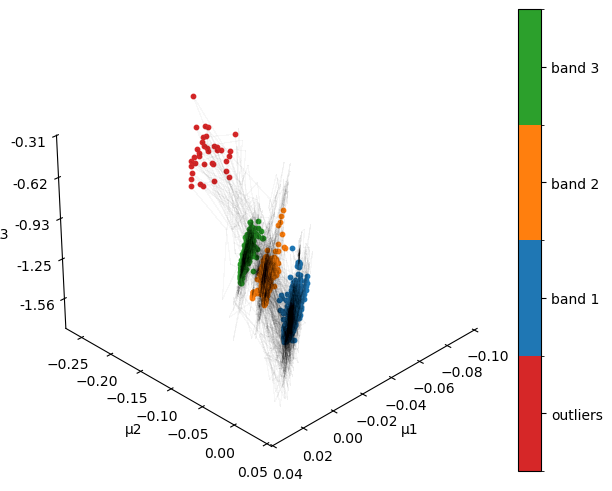

In [147]:
plot_3d_with_pts_all(mu_traj_sim, dots_idx, cols, show_idx = False, alpha = 0.03, labels_all  = titles)

In [148]:
# plot_3d_with_pts(mu_traj_sim, titles[0], dots_idx[0], dot_col =cols[0], show_idx = False, alpha = 0.03)
# plot_3d_with_pts(mu_traj_sim, titles[1], dots_idx[1], dot_col =cols[1], show_idx = False, alpha = 0.03)
# plot_3d_with_pts(mu_traj_sim, titles[2], dots_idx[2], dot_col =cols[2], show_idx = False, alpha = 0.03)
# plot_3d_with_pts(mu_traj_sim, titles[3], dots_idx[3], dot_col =cols[3], show_idx = False, alpha = 0.03)

# 7. Corresponding images

In [149]:
img_data = dset_samples_look[0]
mean_img_data = np.mean(img_data,axis = 0)

## 7.1 |mean(X[group_idx]) - mean(X)|, where X is image

The background = baseline image

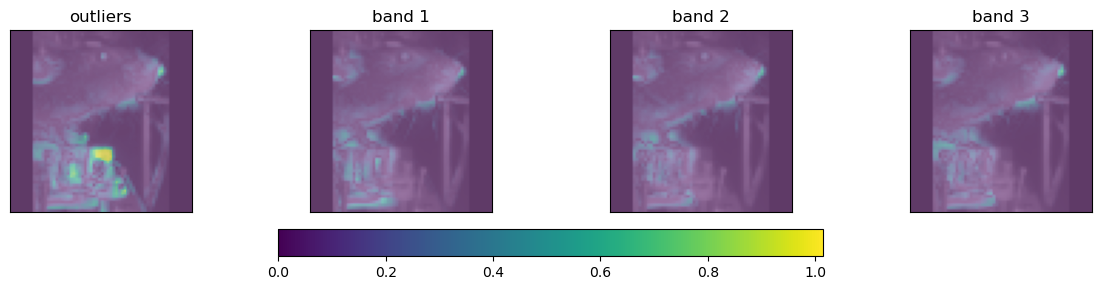

In [150]:
fig, axes = plt.subplots(1, len(dots_idx), figsize=(12, 2.8), constrained_layout=True)
baseline = mean_img
alpha_overlay = 0.55          # constant transparency for the colored layer
img_alpha = 0.5               # keep your base fully visible

cmap = 'viridis'
diffs = [img_data[dots_idx[i]][0,0] - mean_img_data[0] for i in np.arange(len(dots_idx))]
diffs = np.abs(diffs)
vmin = min(d.min() for d in diffs)
vmax = max(d.max() for d in diffs)
norm = mpl.colors.Normalize(vmin=vmin, vmax=vmax)

for ax, i, d in zip(axes, np.arange(len(dots_idx)), diffs):
    ax.imshow(baseline, origin='upper', cmap='gray', alpha=img_alpha)
    ax.imshow(d, origin='upper', cmap=cmap, norm=norm, alpha=alpha_overlay) # colored overlay
    ax.set_xticks([]); ax.set_yticks([])
    ax.set_title(titles[i])

sm = mpl.cm.ScalarMappable(norm=norm, cmap=cmap); sm.set_array([])
fig.colorbar(sm, ax=axes, orientation='horizontal', pad=0.08)

## 7.2 show trend of 3 bands

Let $\mu_i$ be the points in a band. 
1. Find PC1 direction ($v_1$) of the band. Let $Z_i = \mu_i - \bar{\mu}_{band}$, calculate distance along $v_1$ as $t_i = Z_i^\top v_1$.
2. Standardize $t_i$ to $\tilde{t}_i$, having mean 0 and variance 1
3. simply do linear reregression for each pixel $p$: $X_i(p) = \alpha_p + \beta_p\tilde{t}_i + \epsilon_{ip}$.
4. plot heatmap of $\beta_p$ for each pixel

In [151]:
trend1, slims1 = band_trend_maps(img_data, mu_traj_sim[0], dots_idx[1], bins=kk, vclip=0.995)
trend2, slims2 = band_trend_maps(img_data, mu_traj_sim[0], dots_idx[2], bins=kk, vclip=0.995)
trend3, slims3 = band_trend_maps(img_data, mu_traj_sim[0], dots_idx[3], bins=kk, vclip=0.995)

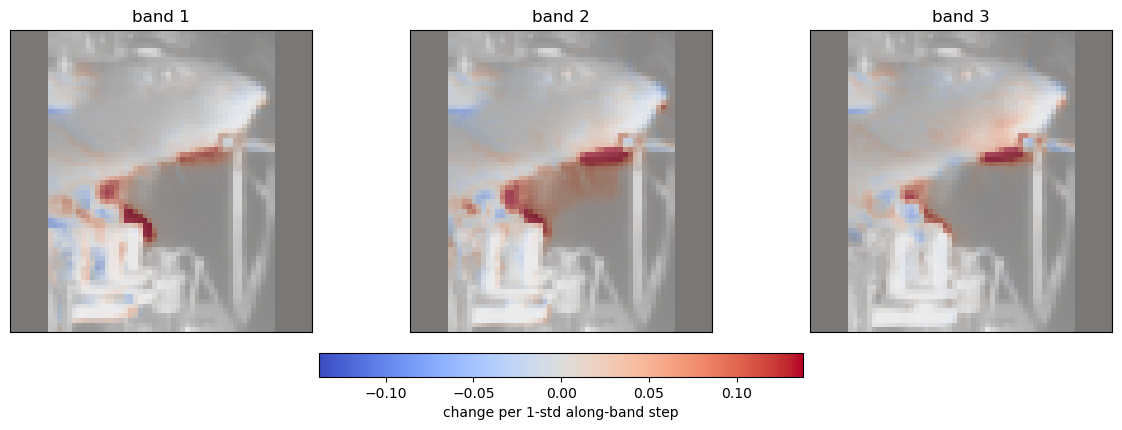

In [152]:
baseline = mean_img
fig, axes, shared_vlims = plot_band_trends_row_simple(
    [trend1, trend2, trend3],
    titles=[titles[1], titles[2], titles[3]],
    baseline=baseline,
    alpha_slope=0.55,  # tweak 0.3–0.7 to taste
    vlims=None,        # or set manually if you want exact reuse of previous limits
    vclip=0.995
)
plt.show()

# 8. Representitive pts

## 8.1 3D plots

In [158]:
kk = 10
dists = torch.linalg.norm(x0 - mu, dim=1)
topk = torch.topk(dists, k=kk)         # largest distances
topk_idx = torch.sort(topk.indices.cpu()).values

In [159]:
medoids1, bins1 = band_bin_medoids(img_data, mu_traj_sim[0], dots_idx[1], bins=kk)
medoids2, bins2 = band_bin_medoids(img_data, mu_traj_sim[0], dots_idx[2], bins=kk)
medoids3, bins3 = band_bin_medoids(img_data, mu_traj_sim[0], dots_idx[3], bins=kk)
dots_rep_idx = [topk_idx, torch.tensor(medoids1), torch.tensor(medoids2), torch.tensor(medoids3)]

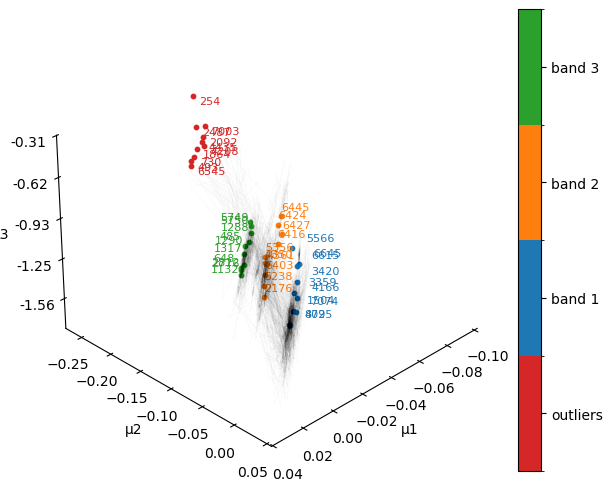

In [160]:
post_adjust = [np.zeros((kk, 3), dtype=float) for _ in range(4)]
post_adjust[0][:, 1] = 0.01
post_adjust[0][:, 2] = -0.04

post_adjust[1][:, 0] = -0.01

post_adjust[2][:, 2] = 0.05

post_adjust[3][:, 1] = -0.05
post_adjust[3][:, 2] = -0.1
plot_3d_with_pts_all(mu_traj_sim, dots_rep_idx, cols, show_idx = True,
                     alpha = 0.01, labels_all  = titles, post_adjust = post_adjust)

## 8.2 The image correspond to each point
For each image, show image at that point as background, and colored with $|X_i - mean(X)|$


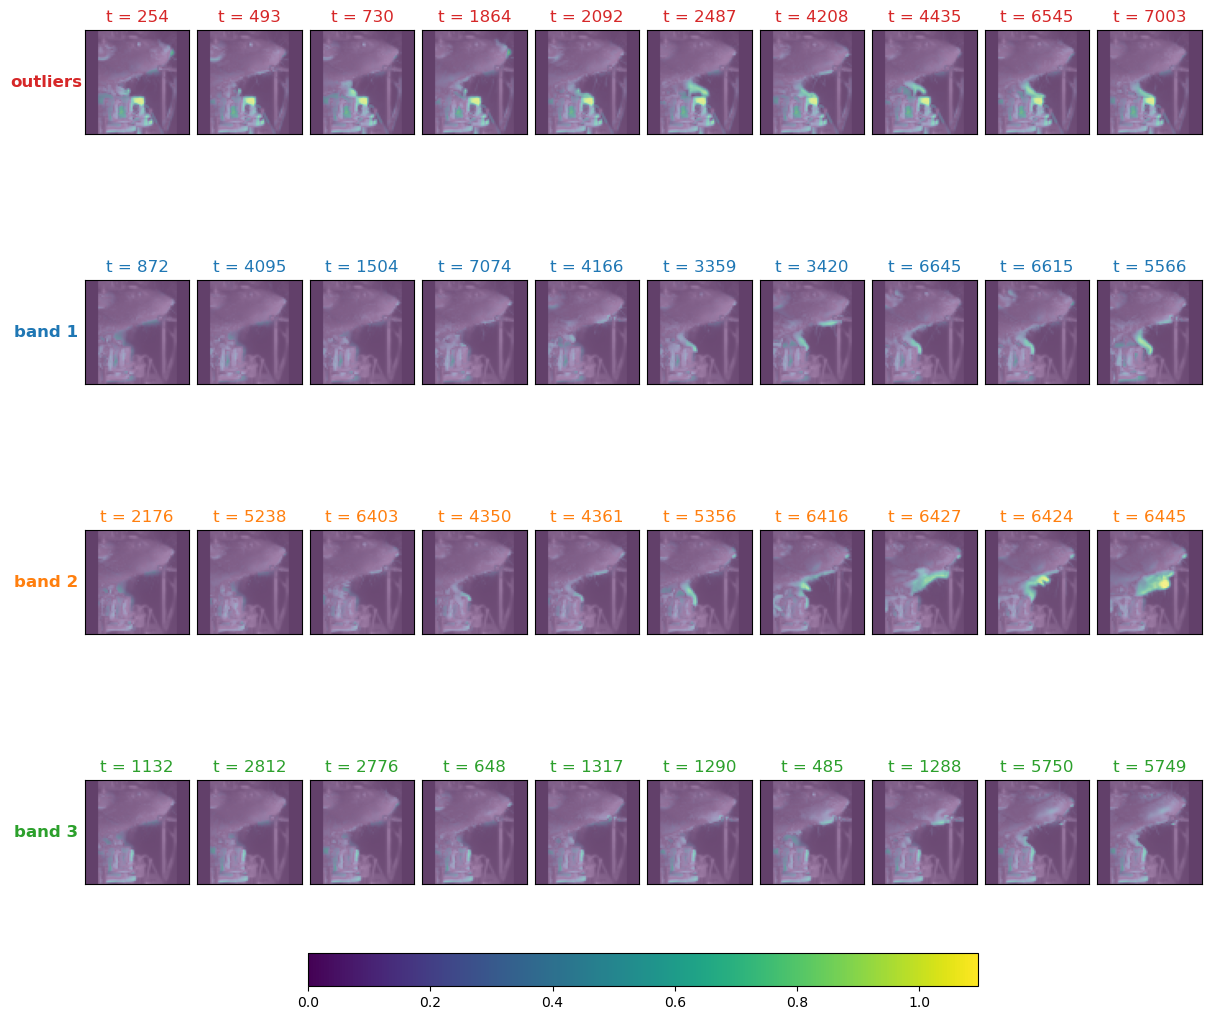

In [161]:
rows, ncols = 4, kk
fig, axes = plt.subplots(rows, ncols, figsize=(12, 2.8 * rows), constrained_layout=True)
baseline = mean_img
alpha_overlay = 0.5
img_alpha = 0.5
cmap = 'viridis'

all_ids = []
for g in range(rows):
    for j in range(ncols):
        idx = dots_rep_idx[g][j]
        idx = int(idx.detach().cpu().numpy()) if hasattr(idx, "detach") else int(idx)
        all_ids.append(idx)
diffs_all = [np.abs(img_data[i][0] - mean_img_data[0]) for i in all_ids]
vmin = min(float(d.min()) for d in diffs_all)
vmax = max(float(d.max()) for d in diffs_all)
norm = mpl.colors.Normalize(vmin=vmin, vmax=vmax)

for g in range(rows):
    for j in range(ncols):
        ax = axes[g, j]
        idx = dots_rep_idx[g][j]
        i = int(idx.detach().cpu().numpy()) if hasattr(idx, "detach") else int(idx)
        d = np.abs(img_data[i][0] - mean_img_data[0])

        ax.imshow(baseline + img_data[dots_rep_idx[g][j]][0], origin='upper', cmap='gray', alpha=img_alpha)
        ax.imshow(d, origin='upper', cmap=cmap, norm=norm, alpha=alpha_overlay)
        ax.set_xticks([]); ax.set_yticks([])
        ax.set_title(f"t = {i + lag}", color=cols[g])

sm = mpl.cm.ScalarMappable(norm=norm, cmap=cmap); sm.set_array([])
fig.colorbar(sm, ax=axes.ravel().tolist(),
             orientation='horizontal', pad=0.06, shrink=0.6)
for g in range(rows):
    axes[g, 0].set_ylabel(
        titles[g],
        rotation=0, labelpad=28, va='center',
        fontsize=12, fontweight='bold',
        color=cols[g]
    )